In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Create app folder
app_path = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app"
os.makedirs(app_path, exist_ok=True)
print(f"✅ App folder ready: {app_path}")

Mounted at /content/drive
✅ App folder ready: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app


In [ ]:
!pip install -q streamlit pyngrok transformers==4.35.0
print("✅ Streamlit installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 13.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.17.3 which is incompatible.
gradio-client 2.5.0 requires huggingface-hub<2.0,>=0.19.3, but you have huggingface-hub 0.17.3 which is incompatible.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.17.3 which is incompatible.
gradio 6.2

In [ ]:
app_path = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app/streamlit_app.py"

with open(app_path, "r") as f:
    content = f.read()

# Switch to V2 model (98.80% accuracy - your latest, best model)
content = content.replace(
    "models/cnn_model/efficientnet_combined_best.pth",
    "models/cnn_model/efficientnet_v2_best.pth"
).replace(
    "models/cnn_model/efficientnet_best.pth",
    "models/cnn_model/efficientnet_v2_best.pth"
)

with open(app_path, "w") as f:
    f.write(content)

print("✅ Switched to V2 model!")
print("   Now using: efficientnet_v2_best.pth (98.80% test accuracy)")

✅ Switched to V2 model!
   Now using: efficientnet_v2_best.pth (98.80% test accuracy)


In [ ]:
from google.colab.output import eval_js
import subprocess, time

subprocess.run(["pkill","-f","streamlit"], capture_output=True)
time.sleep(2)

proc = subprocess.Popen([
    "streamlit","run", app_path,
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false"
])
time.sleep(6)
url = eval_js("google.colab.kernel.proxyPort(8501)")
print(f"🚀 App restarted with original model!")
print(f"   👉 Open: {url}")

🚀 App restarted with original model!
   👉 Open: https://8501-m-s-kkb-use1c2-7q0ofqnt2bu8-c.us-east1-2.prod.colab.dev


In [ ]:
!pip install -q grad-cam

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import cv2
from PIL import Image
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters(): param.requires_grad = False
    for param in m.features[5:].parameters(): param.requires_grad = True
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f,512),
                                  nn.ReLU(), nn.Dropout(p=dropout/2), nn.Linear(512,num_classes))
    return m

MODEL_PATH = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_v2_best.pth"
model = build_efficientnet()
w = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(w['model_state'] if 'model_state' in w else w)
model = model.to(device)
model.eval()

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

# Last conv block of EfficientNetB0 — the standard Grad-CAM target layer for this architecture
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def predict_with_gradcam(image_path):
    pil_img = Image.open(image_path).convert('RGB')
    resized = pil_img.resize((224,224))
    rgb_float = np.array(resized).astype(np.float32) / 255.0

    input_tensor = val_transforms(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(input_tensor), dim=1)
    fake_p = probs[0][0].item() * 100
    real_p = probs[0][1].item() * 100
    pred_class = 0 if fake_p >= 50 else 1   # 0=Fake, 1=Real

    # Grad-CAM heatmap for the PREDICTED class — shows what drove this specific verdict
    grayscale_cam = cam(input_tensor=input_tensor,
                         targets=None)[0]   # None = uses model's own top prediction
    overlay = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

    return resized, overlay, fake_p, real_p

# ── Test on your images ──────────────────────────────────────
from google.colab import files
print("📂 Upload test images (real deepfake, real photo, CGI/meme for comparison)...")
uploaded = files.upload()

for fname in uploaded.keys():
    orig, heatmap, fake_p, real_p = predict_with_gradcam(fname)
    verdict = "FAKE" if fake_p >= 50 else "REAL"

    fig, axes = plt.subplots(1, 2, figsize=(9,4.5))
    axes[0].imshow(orig); axes[0].set_title("Input"); axes[0].axis('off')
    axes[1].imshow(heatmap); axes[1].set_title(f"Grad-CAM — {verdict}"); axes[1].axis('off')
    plt.suptitle(f"{fname} | Real: {real_p:.1f}%  Fake: {fake_p:.1f}%")
    plt.tight_layout()
    plt.show()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 


📂 Upload test images (real deepfake, real photo, CGI/meme for comparison)...


📂 Upload test images (real deepfake, real photo, CGI/meme for comparison)...


Saving IMG20231106151733.jpg to IMG20231106151733 (2).jpg


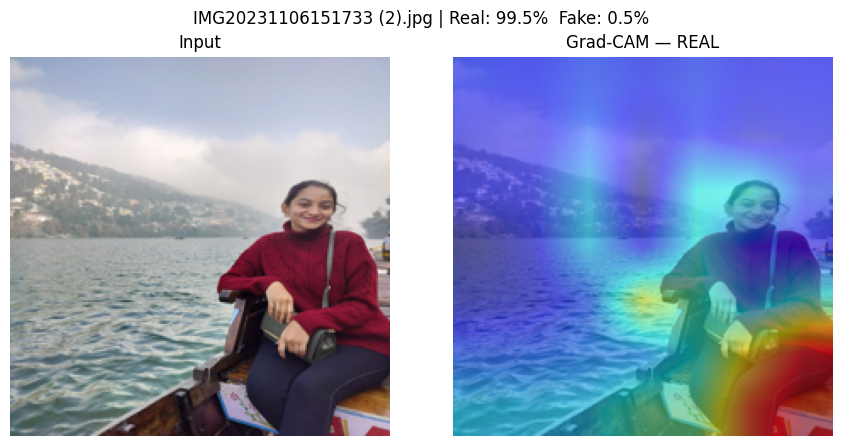

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import cv2
from PIL import Image
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters(): param.requires_grad = False
    for param in m.features[5:].parameters(): param.requires_grad = True
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f,512),
                                  nn.ReLU(), nn.Dropout(p=dropout/2), nn.Linear(512,num_classes))
    return m

MODEL_PATH = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_v2_best.pth"
model = build_efficientnet()
w = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(w['model_state'] if 'model_state' in w else w)
model = model.to(device)
model.eval()

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

# Last conv block of EfficientNetB0 — the standard Grad-CAM target layer for this architecture
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def predict_with_gradcam(image_path):
    pil_img = Image.open(image_path).convert('RGB')
    resized = pil_img.resize((224,224))
    rgb_float = np.array(resized).astype(np.float32) / 255.0

    input_tensor = val_transforms(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(input_tensor), dim=1)
    fake_p = probs[0][0].item() * 100
    real_p = probs[0][1].item() * 100
    pred_class = 0 if fake_p >= 50 else 1   # 0=Fake, 1=Real

    # Grad-CAM heatmap for the PREDICTED class — shows what drove this specific verdict
    grayscale_cam = cam(input_tensor=input_tensor,
                         targets=None)[0]   # None = uses model's own top prediction
    overlay = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

    return resized, overlay, fake_p, real_p

# ── Test on your images ──────────────────────────────────────
from google.colab import files
print("📂 Upload test images (real deepfake, real photo, CGI/meme for comparison)...")
uploaded = files.upload()

for fname in uploaded.keys():
    orig, heatmap, fake_p, real_p = predict_with_gradcam(fname)
    verdict = "FAKE" if fake_p >= 50 else "REAL"

    fig, axes = plt.subplots(1, 2, figsize=(9,4.5))
    axes[0].imshow(orig); axes[0].set_title("Input"); axes[0].axis('off')
    axes[1].imshow(heatmap); axes[1].set_title(f"Grad-CAM — {verdict}"); axes[1].axis('off')
    plt.suptitle(f"{fname} | Real: {real_p:.1f}%  Fake: {fake_p:.1f}%")
    plt.tight_layout()
    plt.show()

📂 Upload ONE real face photo (your own, clearly showing a face)...


Saving IMG20231106151733.jpg to IMG20231106151733 (3).jpg

  DIAGNOSTIC: Does the model need an actual face, or just a
  face-shaped region, to predict REAL?

Original photo (face visible)
   → REAL   Real: 99.5%   Fake: 0.5%

Same photo, face blacked out
   → REAL   Real: 92.6%   Fake: 7.4%

Pure random noise (no structure)
   → REAL   Real: 100.0%   Fake: 0.0%

Flat solid color (nothing at all)
   → FAKE   Real: 28.1%   Fake: 71.9%


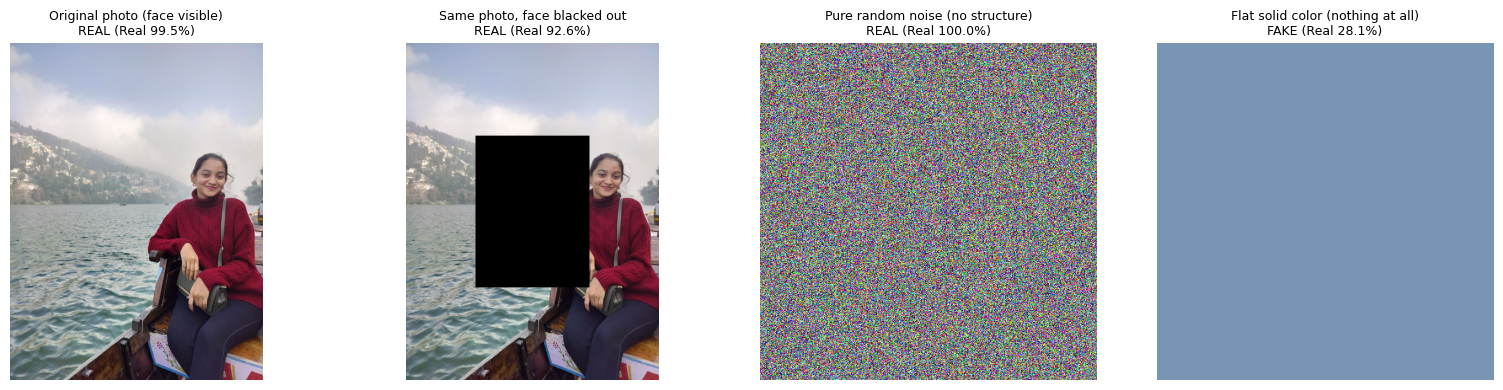

In [ ]:
import torch
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Uses the same model, val_transforms, device already loaded in this notebook

def predict(pil_img):
    t = val_transforms(pil_img.convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(t), dim=1)
    return p[0][0].item()*100, p[0][1].item()*100  # fake%, real%

def black_out_center(pil_img, frac=0.45):
    """Covers the center region (where a face would typically be) with solid black."""
    img = pil_img.convert('RGB').copy()
    w, h = img.size
    bw, bh = int(w*frac), int(h*frac)
    x1, y1 = (w-bw)//2, (h-bh)//2
    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x1+bw, y1+bh], fill=(0,0,0))
    return img

def random_noise_image(size=(400,400)):
    """Pure random noise — no face, no structure at all."""
    arr = np.random.randint(0, 255, (size[1], size[0], 3), dtype=np.uint8)
    return Image.fromarray(arr)

def solid_color_image(color=(120,150,180), size=(400,400)):
    """A flat solid-color image — nothing for any 'face prior' to latch onto."""
    return Image.new('RGB', size, color)

# ── Run the diagnostic ────────────────────────────────────────
from google.colab import files
print("📂 Upload ONE real face photo (your own, clearly showing a face)...")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
orig = Image.open(fname).convert('RGB')

blacked = black_out_center(orig, frac=0.45)
noise   = random_noise_image()
solid   = solid_color_image()

tests = [
    ("Original photo (face visible)", orig),
    ("Same photo, face blacked out",  blacked),
    ("Pure random noise (no structure)", noise),
    ("Flat solid color (nothing at all)", solid),
]

fig, axes = plt.subplots(1, 4, figsize=(16,4))
print("\n" + "="*65)
print("  DIAGNOSTIC: Does the model need an actual face, or just a")
print("  face-shaped region, to predict REAL?")
print("="*65)

for ax, (label, img) in zip(axes, tests):
    fake_p, real_p = predict(img)
    verdict = "FAKE" if fake_p >= 50 else "REAL"
    ax.imshow(img)
    ax.set_title(f"{label}\n{verdict} (Real {real_p:.1f}%)", fontsize=9)
    ax.axis('off')
    print(f"\n{label}")
    print(f"   → {verdict}   Real: {real_p:.1f}%   Fake: {fake_p:.1f}%")

plt.tight_layout()
plt.show()
print("\n" + "="*65)

📂 Upload ONE real face photo (your own, clearly showing a face)...


Saving 00PYA83V1P.jpg to 00PYA83V1P (1).jpg

  DIAGNOSTIC: Does the model need an actual face, or just a
  face-shaped region, to predict REAL?

Original photo (face visible)
   → FAKE   Real: 0.0%   Fake: 100.0%

Same photo, face blacked out
   → FAKE   Real: 0.4%   Fake: 99.6%

Pure random noise (no structure)
   → REAL   Real: 100.0%   Fake: 0.0%

Flat solid color (nothing at all)
   → FAKE   Real: 28.1%   Fake: 71.9%


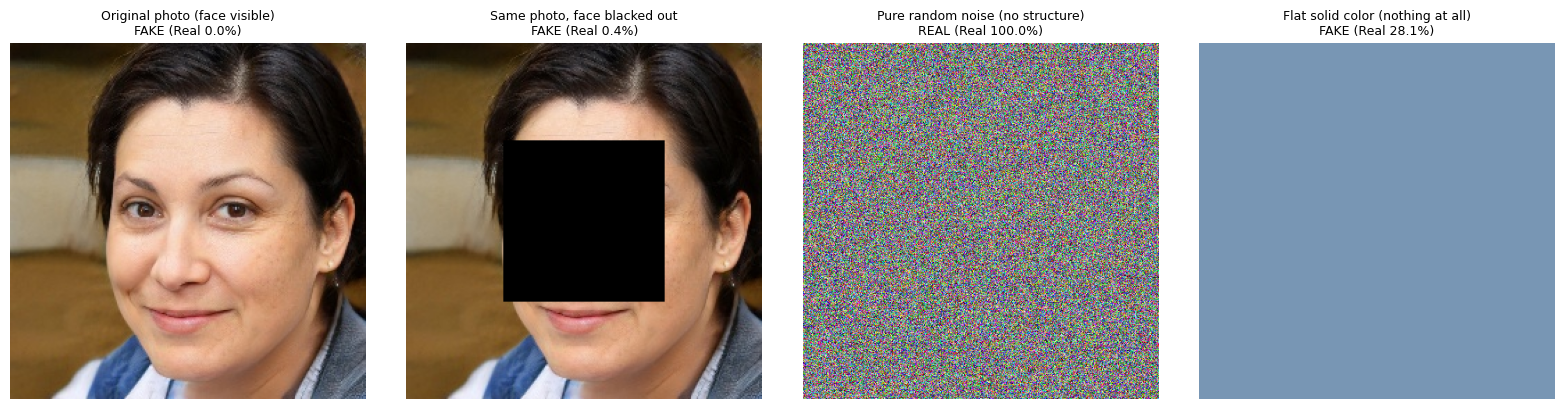

In [ ]:
import torch
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Uses the same model, val_transforms, device already loaded in this notebook

def predict(pil_img):
    t = val_transforms(pil_img.convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(t), dim=1)
    return p[0][0].item()*100, p[0][1].item()*100  # fake%, real%

def black_out_center(pil_img, frac=0.45):
    """Covers the center region (where a face would typically be) with solid black."""
    img = pil_img.convert('RGB').copy()
    w, h = img.size
    bw, bh = int(w*frac), int(h*frac)
    x1, y1 = (w-bw)//2, (h-bh)//2
    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x1+bw, y1+bh], fill=(0,0,0))
    return img

def random_noise_image(size=(400,400)):
    """Pure random noise — no face, no structure at all."""
    arr = np.random.randint(0, 255, (size[1], size[0], 3), dtype=np.uint8)
    return Image.fromarray(arr)

def solid_color_image(color=(120,150,180), size=(400,400)):
    """A flat solid-color image — nothing for any 'face prior' to latch onto."""
    return Image.new('RGB', size, color)

# ── Run the diagnostic ────────────────────────────────────────
from google.colab import files
print("📂 Upload ONE real face photo (your own, clearly showing a face)...")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
orig = Image.open(fname).convert('RGB')

blacked = black_out_center(orig, frac=0.45)
noise   = random_noise_image()
solid   = solid_color_image()

tests = [
    ("Original photo (face visible)", orig),
    ("Same photo, face blacked out",  blacked),
    ("Pure random noise (no structure)", noise),
    ("Flat solid color (nothing at all)", solid),
]

fig, axes = plt.subplots(1, 4, figsize=(16,4))
print("\n" + "="*65)
print("  DIAGNOSTIC: Does the model need an actual face, or just a")
print("  face-shaped region, to predict REAL?")
print("="*65)

for ax, (label, img) in zip(axes, tests):
    fake_p, real_p = predict(img)
    verdict = "FAKE" if fake_p >= 50 else "REAL"
    ax.imshow(img)
    ax.set_title(f"{label}\n{verdict} (Real {real_p:.1f}%)", fontsize=9)
    ax.axis('off')
    print(f"\n{label}")
    print(f"   → {verdict}   Real: {real_p:.1f}%   Fake: {fake_p:.1f}%")

plt.tight_layout()
plt.show()
print("\n" + "="*65)

📂 Upload ONE real face photo (your own, clearly showing a face)...


Saving a949303df9fca80e03c0affe7bbad12a.jpg to a949303df9fca80e03c0affe7bbad12a.jpg

  DIAGNOSTIC: Does the model need an actual face, or just a
  face-shaped region, to predict REAL?

Original photo (face visible)
   → REAL   Real: 100.0%   Fake: 0.0%

Same photo, face blacked out
   → REAL   Real: 98.3%   Fake: 1.7%

Pure random noise (no structure)
   → REAL   Real: 100.0%   Fake: 0.0%

Flat solid color (nothing at all)
   → FAKE   Real: 28.1%   Fake: 71.9%


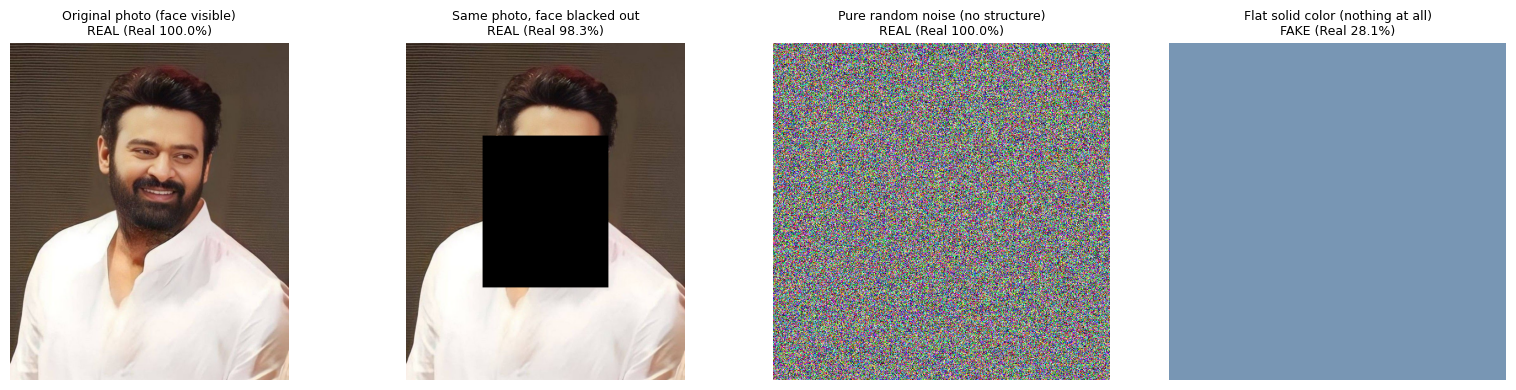

In [ ]:
import torch
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Uses the same model, val_transforms, device already loaded in this notebook

def predict(pil_img):
    t = val_transforms(pil_img.convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(t), dim=1)
    return p[0][0].item()*100, p[0][1].item()*100  # fake%, real%

def black_out_center(pil_img, frac=0.45):
    """Covers the center region (where a face would typically be) with solid black."""
    img = pil_img.convert('RGB').copy()
    w, h = img.size
    bw, bh = int(w*frac), int(h*frac)
    x1, y1 = (w-bw)//2, (h-bh)//2
    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x1+bw, y1+bh], fill=(0,0,0))
    return img

def random_noise_image(size=(400,400)):
    """Pure random noise — no face, no structure at all."""
    arr = np.random.randint(0, 255, (size[1], size[0], 3), dtype=np.uint8)
    return Image.fromarray(arr)

def solid_color_image(color=(120,150,180), size=(400,400)):
    """A flat solid-color image — nothing for any 'face prior' to latch onto."""
    return Image.new('RGB', size, color)

# ── Run the diagnostic ────────────────────────────────────────
from google.colab import files
print("📂 Upload ONE real face photo (your own, clearly showing a face)...")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
orig = Image.open(fname).convert('RGB')

blacked = black_out_center(orig, frac=0.45)
noise   = random_noise_image()
solid   = solid_color_image()

tests = [
    ("Original photo (face visible)", orig),
    ("Same photo, face blacked out",  blacked),
    ("Pure random noise (no structure)", noise),
    ("Flat solid color (nothing at all)", solid),
]

fig, axes = plt.subplots(1, 4, figsize=(16,4))
print("\n" + "="*65)
print("  DIAGNOSTIC: Does the model need an actual face, or just a")
print("  face-shaped region, to predict REAL?")
print("="*65)

for ax, (label, img) in zip(axes, tests):
    fake_p, real_p = predict(img)
    verdict = "FAKE" if fake_p >= 50 else "REAL"
    ax.imshow(img)
    ax.set_title(f"{label}\n{verdict} (Real {real_p:.1f}%)", fontsize=9)
    ax.axis('off')
    print(f"\n{label}")
    print(f"   → {verdict}   Real: {real_p:.1f}%   Fake: {fake_p:.1f}%")

plt.tight_layout()
plt.show()
print("\n" + "="*65)

In [ ]:
app_path = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app/streamlit_app.py"
with open(app_path,"r") as f: content = f.read()
content = content.replace(
    "models/cnn_model/efficientnet_v2_best.pth",
    "models/cnn_model/efficientnet_v3_best.pth")
with open(app_path,"w") as f: f.write(content)
print("✅ Streamlit updated to V3!")

✅ Streamlit updated to V3!


In [ ]:
app_path = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app/streamlit_app.py"

with open(app_path, "r") as f:
    content = f.read()

# Update model path to V3
content = content.replace(
    "models/cnn_model/efficientnet_v2_best.pth",
    "models/cnn_model/efficientnet_v3_best.pth"
).replace(
    "models/cnn_model/efficientnet_combined_best.pth",
    "models/cnn_model/efficientnet_v3_best.pth"
).replace(
    "models/cnn_model/efficientnet_best.pth",
    "models/cnn_model/efficientnet_v3_best.pth"
)

# Update accuracy display to V3 results
content = content.replace(
    "CNN V2 — Image','98.80%",
    "CNN V3 — Image','92.34%"
).replace(
    "CNN — Image','97.72%",
    "CNN V3 — Image','92.34%"
)

with open(app_path, "w") as f:
    f.write(content)

print("✅ Streamlit updated to V3 model!")

# Verify
with open(app_path, "r") as f:
    for line in f:
        if "efficientnet" in line.lower() and "pth" in line:
            print(f"   Model path: {line.strip()}")
            break

✅ Streamlit updated to V3 model!
   Model path: CNN_PATH  = os.path.join(BASE_PATH,'models/cnn_model/efficientnet_v3_best.pth')


In [ ]:
import os
ASSETS = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app/assets"
os.makedirs(ASSETS, exist_ok=True)
print("Files in assets folder:")
for f in os.listdir(ASSETS):
    print(f"  ✅ {f}")

Files in assets folder:
  ✅ hero_image.png
  ✅ fake_news.png
  ✅ image_detect.png
  ✅ video_detect.png
  ✅ logo.png
  ✅ fusion.png


In [ ]:
app_path = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app/streamlit_app.py"
ASSETS   = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app/assets"

import base64, os

def img_to_b64(path):
    if os.path.exists(path):
        with open(path,"rb") as f:
            return base64.b64encode(f.read()).decode()
    return ""

logo_b64  = img_to_b64(f"{ASSETS}/logo.png")
hero_b64  = img_to_b64(f"{ASSETS}/hero_image.png")
fn_b64    = img_to_b64(f"{ASSETS}/fake_news.png")
img_b64   = img_to_b64(f"{ASSETS}/image_detect.png")
vid_b64   = img_to_b64(f"{ASSETS}/video_detect.png")
fus_b64   = img_to_b64(f"{ASSETS}/fusion.png")

print("Assets loaded:")
for name,b64 in [("logo",logo_b64),("hero",hero_b64),("fake_news",fn_b64),
                  ("image_detect",img_b64),("video_detect",vid_b64),("fusion",fus_b64)]:
    print(f"  {'✅' if b64 else '❌'} {name}: {len(b64)} chars")

Assets loaded:
  ✅ logo: 947808 chars
  ✅ hero: 4179760 chars
  ✅ fake_news: 4233160 chars
  ✅ image_detect: 5040744 chars
  ✅ video_detect: 4523956 chars
  ✅ fusion: 805984 chars


In [ ]:
code = [
"import streamlit as st",
"import torch, torch.nn as nn, numpy as np, cv2, os, tempfile, base64",
"from PIL import Image, ImageDraw",
"from torchvision import transforms, models",
"from transformers import BertTokenizer, BertForSequenceClassification",
"from pytorch_grad_cam import GradCAM",
"from pytorch_grad_cam.utils.image import show_cam_on_image",
"import io",
"",
"st.set_page_config(page_title='FakeDetect', page_icon='👁️', layout='wide', initial_sidebar_state='collapsed')",
"",
"# ── Base64 assets ─────────────────────────────────────────────",
f"LOGO_B64 = '{logo_b64}'",
f"HERO_B64 = '{hero_b64}'",
f"FN_B64   = '{fn_b64}'",
f"IMG_B64  = '{img_b64}'",
f"VID_B64  = '{vid_b64}'",
f"FUS_B64  = '{fus_b64}'",
"",
"def b64img(b64, ext='png'):",
"    return f'data:image/{ext};base64,{b64}'",
"",
"st.markdown('''<style>",
"@import url(\"https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap\");",
"html,body,[class*=\"css\"]{font-family:\"Inter\",sans-serif!important;}",
".stApp{background:#F0FBFF;}",
"section[data-testid=\"stSidebar\"]{display:none;}",
".stButton>button{background:white;border:1.5px solid #02cdff;color:#0099CC;border-radius:8px;font-weight:600;padding:8px 20px;transition:all .2s;}",
".stButton>button:hover{background:#02cdff;color:white;}",
".stButton>button[kind=\"primary\"]{background:#02cdff;color:white;border-color:#02cdff;}",
".stButton>button[kind=\"primary\"]:hover{background:#00b5e6;}",
".stTabs [data-baseweb=\"tab-list\"]{background:white;border-radius:12px;padding:6px;border:1.5px solid #D0F4FF;gap:4px;}",
".stTabs [data-baseweb=\"tab\"]{border-radius:9px;color:#4A6B85;font-weight:600;font-size:13px;padding:8px 18px;}",
".stTabs [aria-selected=\"true\"]{background:#02cdff!important;color:white!important;}",
".stTabs [data-baseweb=\"tab-highlight\"]{display:none!important;}",
".stTabs [data-baseweb=\"tab-border\"]{display:none!important;}",
".stTextArea textarea{background:white!important;border:1.5px solid #B0ECFF!important;border-radius:10px!important;color:#0A2540!important;}",
"div[data-testid=\"stFileUploader\"]{background:white;border:2px dashed #B0ECFF;border-radius:12px;}",
"div[data-testid=\"stFileUploader\"]:hover{border-color:#02cdff;}",
".stSuccess{background:#E8FFF3!important;border:1px solid #6EE7B7!important;border-radius:10px!important;}",
".stInfo{background:#E8FAFF!important;border:1px solid #B0ECFF!important;border-radius:10px!important;}",
"div[data-testid=\"stDataFrame\"]{border-radius:12px;overflow:hidden;border:1.5px solid #D0F4FF!important;}",
"h1,h2,h3,h4{color:#0A2540!important;}",
"p,label,.stMarkdown{color:#334155;}",
"</style>''', unsafe_allow_html=True)",
"",
"BASE_PATH = '/content/drive/MyDrive/AI_FakeNews_Deepfake_Project'",
"BERT_PATH = os.path.join(BASE_PATH,'models/bert_model')",
"CNN_PATH  = os.path.join(BASE_PATH,'models/cnn_model/efficientnet_v3_best.pth')",
"DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')",
"",
"@st.cache_resource",
"def load_models():",
"    tok  = BertTokenizer.from_pretrained(BERT_PATH)",
"    bert = BertForSequenceClassification.from_pretrained(BERT_PATH).to(DEVICE)",
"    bert.eval()",
"    m = models.efficientnet_b0(weights=None)",
"    inf = m.classifier[1].in_features",
"    m.classifier = nn.Sequential(nn.Dropout(0.3),nn.Linear(inf,512),nn.ReLU(),nn.Dropout(0.15),nn.Linear(512,2))",
"    w = torch.load(CNN_PATH, map_location=DEVICE)",
"    if any(k.startswith('module.') for k in w.keys()):",
"        w = {k.replace('module.',''):v for k,v in w.items()}",
"    m.load_state_dict(w)",
"    m.to(DEVICE).eval()",
"    return tok, bert, m",
"",
"base_tfm = transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])",
"flip_tfm = transforms.Compose([transforms.Resize((224,224)),transforms.RandomHorizontalFlip(p=1.0),transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])",
"crop_tfm = transforms.Compose([transforms.Resize((256,256)),transforms.CenterCrop(224),transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])",
"",
"def pred_text(text,tok,bert):",
"    e=tok(text.lower().strip(),max_length=128,truncation=True,padding='max_length',return_tensors='pt')",
"    with torch.no_grad(): p=torch.softmax(bert(input_ids=e['input_ids'].to(DEVICE),attention_mask=e['attention_mask'].to(DEVICE)).logits,dim=1)",
"    return p[0][1].item()",
"",
"def pred_img_tta(pil_img,cnn):",
"    img=pil_img.convert('RGB')",
"    probs=[]",
"    for tfm in [base_tfm,flip_tfm,crop_tfm]:",
"        t=tfm(img).unsqueeze(0).to(DEVICE)",
"        with torch.no_grad(): p=torch.softmax(cnn(t),dim=1)",
"        probs.append(p[0].cpu().numpy())",
"    avg=np.mean(probs,axis=0)",
"    return avg[0],avg[1]",
"",
"def get_gradcam_overlay(pil_img, cnn, is_fake):",
"    try:",
"        img_resized = pil_img.convert('RGB').resize((224,224))",
"        rgb = np.array(img_resized).astype(np.float32)/255.0",
"        t   = base_tfm(pil_img.convert('RGB')).unsqueeze(0).to(DEVICE)",
"        cam = GradCAM(model=cnn, target_layers=[cnn.features[-1]])",
"        gs  = cam(input_tensor=t, targets=None)[0]",
"        # Find peak attention region",
"        h, w  = gs.shape",
"        flat  = gs.flatten()",
"        topk  = np.argsort(flat)[-int(len(flat)*0.15):]",
"        ys, xs = np.unravel_index(topk, (h,w))",
"        y1,y2 = max(0,int(ys.min())-5), min(h,int(ys.max())+5)",
"        x1,x2 = max(0,int(xs.min())-5), min(w,int(xs.max())+5)",
"        # Draw rectangle on image",
"        pil_draw = img_resized.copy()",
"        draw = ImageDraw.Draw(pil_draw)",
"        color = '#FF2222' if is_fake else '#02cdff'",
"        for thickness in range(3):",
"            draw.rectangle([x1+thickness,y1+thickness,x2-thickness,y2-thickness],",
"                           outline=color)",
"        # Draw corner markers",
"        corner_len = 15",
"        for cx,cy in [(x1,y1),(x2,y1),(x1,y2),(x2,y2)]:",
"            draw.line([(cx,cy),(cx+corner_len if cx==x1 else cx-corner_len,cy)],fill=color,width=3)",
"            draw.line([(cx,cy),(cx,cy+corner_len if cy==y1 else cy-corner_len)],fill=color,width=3)",
"        return pil_draw",
"    except: return pil_img",
"",
"def pred_vid(path,cnn,n=20):",
"    cap=cv2.VideoCapture(path)",
"    tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))",
"    fps=cap.get(cv2.CAP_PROP_FPS)",
"    dur=tot/fps if fps>0 else 0",
"    if tot==0: cap.release(); return None,[],0",
"    probs,frames=[],[]",
"    for i in np.linspace(0,tot-1,min(n,tot),dtype=int):",
"        cap.set(cv2.CAP_PROP_POS_FRAMES,i)",
"        ret,fr=cap.read()",
"        if ret:",
"            img=Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))",
"            fp,rp=pred_img_tta(img,cnn)",
"            probs.append(fp)",
"            if len(frames)<4: frames.append(img)",
"    cap.release()",
"    return (np.mean(probs) if probs else None),frames,dur",
"",
"def verdict_card(is_fake,fp,rp):",
"    bg  = 'linear-gradient(135deg,#FFF0F0,#FFE0E0)' if is_fake else 'linear-gradient(135deg,#E8FFF3,#C6F6E0)'",
"    bc  = '#FFAAAA' if is_fake else '#6EE7B7'",
"    tc  = '#CC2B2B' if is_fake else '#00895A'",
"    txt = 'FAKE DETECTED' if is_fake else 'REAL CONTENT'",
"    st.markdown(f'<div style=\"background:{bg};border:2px solid {bc};border-radius:14px;padding:14px;text-align:center;color:{tc};font-size:1.2rem;font-weight:700;margin:12px 0;\">{txt}</div>',unsafe_allow_html=True)",
"    st.markdown(f'<div style=\"display:grid;grid-template-columns:1fr 1fr;gap:10px;margin:10px 0;\"><div style=\"background:#FFF0F0;border:1px solid #FFD0D0;border-radius:10px;padding:10px;text-align:center;\"><div style=\"font-size:10px;color:#CC2B2B;font-weight:700;text-transform:uppercase;letter-spacing:.05em;\">Fake confidence</div><div style=\"font-size:20px;font-weight:700;color:#CC2B2B;\">{fp:.1f}%</div></div><div style=\"background:#E8FFF3;border:1px solid #A7F3D0;border-radius:10px;padding:10px;text-align:center;\"><div style=\"font-size:10px;color:#00895A;font-weight:700;text-transform:uppercase;letter-spacing:.05em;\">Real confidence</div><div style=\"font-size:20px;font-weight:700;color:#00895A;\">{rp:.1f}%</div></div></div>',unsafe_allow_html=True)",
"    c1,c2=st.columns(2)",
"    with c1: st.caption('Fake'); st.progress(int(fp))",
"    with c2: st.caption('Real'); st.progress(int(rp))",
"",
"def why_card(scores):",
"    rows=''",
"    if 'text'  in scores:",
"        dot='🔴' if scores['text']>=0.5  else '🟢'",
"        rows+=f'<div style=\"padding:5px 0;font-size:13px;color:#334155;border-bottom:1px solid #E8FAFF;\">{dot} Text model: {\"Misinformation patterns detected\" if scores[\"text\"]>=0.5 else \"Credible language found\"}</div>'",
"    if 'image' in scores:",
"        dot='🔴' if scores['image']>=0.5 else '🟢'",
"        rows+=f'<div style=\"padding:5px 0;font-size:13px;color:#334155;border-bottom:1px solid #E8FAFF;\">{dot} Image model: {\"Deepfake or AI-generation artifacts found\" if scores[\"image\"]>=0.5 else \"No manipulation artifacts detected\"}</div>'",
"    if 'video' in scores:",
"        dot='🔴' if scores['video']>=0.5 else '🟢'",
"        rows+=f'<div style=\"padding:5px 0;font-size:13px;color:#334155;\">{dot} Video model: {\"AI-generated or manipulated frames detected\" if scores[\"video\"]>=0.5 else \"Video frames appear authentic\"}</div>'",
"    st.markdown(f'<div style=\"background:#F0FBFF;border-left:4px solid #02cdff;border-radius:0 10px 10px 0;padding:14px 16px;margin:12px 0;\"><div style=\"font-size:10px;font-weight:700;color:#02cdff;text-transform:uppercase;letter-spacing:.08em;margin-bottom:8px;\">Why this verdict?</div>{rows}</div>',unsafe_allow_html=True)",
"",
"def show_result(scores,weights):",
"    tw=sum(weights[k] for k in scores)",
"    nw={k:weights[k]/tw for k in scores}",
"    fs=sum(scores[k]*nw[k] for k in scores)",
"    fp=fs*100; rp=(1-fs)*100",
"    verdict_card(fs>=0.5,fp,rp)",
"    why_card(scores)",
"    st.caption(f\"Method: TTA 3-pass · Fusion weights: {' | '.join([f'{k} {nw[k]*100:.0f}%' for k in nw])}\")",
"",
"def blue_icon(icon_svg):",
"    return f'<div style=\"width:44px;height:44px;background:#E8FAFF;border:1.5px solid #B0ECFF;border-radius:10px;display:flex;align-items:center;justify-content:center;margin:0 auto 10px;\">{icon_svg}</div>'",
"",
"# SVG icons in #02cdff",
"SVG = {",
"'brain': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><path d=\"M9.5 2A2.5 2.5 0 0 1 12 4.5v15a2.5 2.5 0 0 1-4.96-.46 2.5 2.5 0 0 1-2.96-3.08 3 3 0 0 1-.34-5.58 2.5 2.5 0 0 1 1.32-4.24 2.5 2.5 0 0 1 4.44-1.14Z\"/><path d=\"M14.5 2A2.5 2.5 0 0 0 12 4.5v15a2.5 2.5 0 0 0 4.96-.46 2.5 2.5 0 0 0 2.96-3.08 3 3 0 0 0 .34-5.58 2.5 2.5 0 0 0-1.32-4.24 2.5 2.5 0 0 0-4.44-1.14Z\"/></svg>',",
"'target': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><circle cx=\"12\" cy=\"12\" r=\"10\"/><circle cx=\"12\" cy=\"12\" r=\"6\"/><circle cx=\"12\" cy=\"12\" r=\"2\"/></svg>',",
"'eye': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><path d=\"M2 12s3-7 10-7 10 7 10 7-3 7-10 7-10-7-10-7Z\"/><circle cx=\"12\" cy=\"12\" r=\"3\"/></svg>',",
"'scan': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><path d=\"M3 7V5a2 2 0 0 1 2-2h2M17 3h2a2 2 0 0 1 2 2v2M21 17v2a2 2 0 0 1-2 2h-2M7 21H5a2 2 0 0 1-2-2v-2\"/><line x1=\"3\" y1=\"12\" x2=\"21\" y2=\"12\"/></svg>',",
"'refresh': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><path d=\"M3 12a9 9 0 0 1 9-9 9.75 9.75 0 0 1 6.74 2.74L21 8\"/><path d=\"M21 3v5h-5\"/><path d=\"M21 12a9 9 0 0 1-9 9 9.75 9.75 0 0 1-6.74-2.74L3 16\"/><path d=\"M3 21v-5h5\"/></svg>',",
"'db': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><ellipse cx=\"12\" cy=\"5\" rx=\"9\" ry=\"3\"/><path d=\"M21 12c0 1.66-4 3-9 3s-9-1.34-9-3\"/><path d=\"M3 5v14c0 1.66 4 3 9 3s9-1.34 9-3V5\"/></svg>',",
"'shield': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><path d=\"M12 22s8-4 8-10V5l-8-3-8 3v7c0 6 8 10 8 10z\"/></svg>',",
"'monitor': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><rect x=\"2\" y=\"3\" width=\"20\" height=\"14\" rx=\"2\"/><line x1=\"8\" y1=\"21\" x2=\"16\" y2=\"21\"/><line x1=\"12\" y1=\"17\" x2=\"12\" y2=\"21\"/></svg>',",
"'bolt': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><polygon points=\"13 2 3 14 12 14 11 22 21 10 12 10 13 2\"/></svg>',",
"'news': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><path d=\"M4 22h16a2 2 0 0 0 2-2V4a2 2 0 0 0-2-2H8a2 2 0 0 0-2 2v16a2 2 0 0 0-1.757 1.03A1 1 0 0 1 4 22z\"/><line x1=\"16\" y1=\"13\" x2=\"8\" y2=\"13\"/><line x1=\"16\" y1=\"17\" x2=\"8\" y2=\"17\"/><polyline points=\"10 9 9 9 8 9\"/></svg>',",
"'video': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><polygon points=\"23 7 16 12 23 17 23 7\"/><rect x=\"1\" y=\"5\" width=\"15\" height=\"14\" rx=\"2\"/></svg>',",
"'link': '<svg width=22 height=22 viewBox=\"0 0 24 24\" fill=\"none\" stroke=\"#02cdff\" stroke-width=\"2\"><path d=\"M10 13a5 5 0 0 0 7.54.54l3-3a5 5 0 0 0-7.07-7.07l-1.72 1.71\"/><path d=\"M14 11a5 5 0 0 0-7.54-.54l-3 3a5 5 0 0 0 7.07 7.07l1.71-1.71\"/></svg>',",
"}",
"",
"# ── NAV ──────────────────────────────────────────────────────",
"logo_html = f'<img src=\"data:image/png;base64,{LOGO_B64}\" style=\"height:50px;width:50px;object-fit:contain;border-radius:8px;\"/>' if LOGO_B64 else '<div style=\"width:36px;height:36px;background:linear-gradient(135deg,#02cdff,#0099CC);border-radius:8px;\"></div>'",
"st.markdown(f'''<div style=\"background:white;border-bottom:2px solid #D0F4FF;padding:12px 28px;display:flex;align-items:center;justify-content:space-between;\">",
"<div style=\"display:flex;align-items:center;gap:12px;\">{logo_html}<span style=\"font-size:30px;font-weight:700;color:#0A2540;\">Fake<span style='color:#02cdff'>Detect</span></span></div>",

"</div>''', unsafe_allow_html=True)",
"",
"tabs = st.tabs(['  Home  ','  Detection  ','  Features  ','  Technology  ','  Statistics  ','  About  '])",
"",
"# ════════════════════════════════════════════════════════════",
"# HOME",
"# ════════════════════════════════════════════════════════════",
"with tabs[0]:",
"    hero_right = f'<img src=\"data:image/png;base64,{HERO_B64}\" style=\"width:100%;height:100%;object-fit:cover;border-radius:14px;\"/>' if HERO_B64 else '<div style=\"background:linear-gradient(135deg,#E8FAFF,#D0F4FF);height:280px;border-radius:14px;display:flex;align-items:center;justify-content:center;font-size:48px;\">🛡️</div>'",
"    st.markdown(f'''<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:20px;padding:40px;margin:20px 0;\">",
"    <div style=\"display:grid;grid-template-columns:1fr 420px;gap:40px;align-items:center;\">",
"    <div>",
"    <div style=\"font-size:20px;font-weight:700;color:#02cdff;text-transform:uppercase;letter-spacing:.12em;margin-bottom:12px;\">AI-Powered Detection System</div>",
"    <div style=\"font-size:38px;font-weight:700;color:#0A2540;line-height:1.15;margin-bottom:14px;\">Detect <span style='color:#02cdff'>Deepfakes</span> &amp; Fake News Instantly</div>",
"    <div style=\"font-size:15px;color:#4A6B85;line-height:1.8;margin-bottom:20px;\">FakeDetect is a multimodal AI system combining BERT, EfficientNetB0 V3, and Grad-CAM to detect fake news, AI-generated images, deepfake faces, and manipulated videos - all in one unified platform.</div>",
"    <div style=\"display:flex;gap:8px;flex-wrap:wrap;\">",
"    <span style=\"background:#E8FAFF;color:#0099CC;border:1.5px solid #B0ECFF;border-radius:20px;padding:5px 14px;font-size:12px;font-weight:600;\">Text Analysis</span>",
"    <span style=\"background:#E8FAFF;color:#0099CC;border:1.5px solid #B0ECFF;border-radius:20px;padding:5px 14px;font-size:12px;font-weight:600;\">Image Detection</span>",
"    <span style=\"background:#E8FAFF;color:#0099CC;border:1.5px solid #B0ECFF;border-radius:20px;padding:5px 14px;font-size:12px;font-weight:600;\">Video Analysis</span>",
"    <span style=\"background:#E8FFF3;color:#00895A;border:1.5px solid #A7F3D0;border-radius:20px;padding:5px 14px;font-size:12px;font-weight:600;\">Grad-CAM</span>",
"    <span style=\"background:#E8FFF3;color:#00895A;border:1.5px solid #A7F3D0;border-radius:20px;padding:5px 14px;font-size:12px;font-weight:600;\">TTA Stabilised</span>",
"    <span style=\"background:#FFF8E1;color:#B45309;border:1.5px solid #FCD34D;border-radius:20px;padding:5px 14px;font-size:12px;font-weight:600;\">Multimodal Fusion</span>",
"    </div></div>",
"    <div>{hero_right}</div>",
"    </div></div>''', unsafe_allow_html=True)",
"",
"    c1,c2,c3,c4 = st.columns(4)",
"    for col,val,label in [(c1,'99.13%','Text accuracy'),(c2,'92.34%','Image accuracy'),(c3,'99.89%','Video accuracy'),(c4,'286K+','Training samples')]:",
"        col.markdown(f'<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:12px;padding:16px;text-align:center;margin-top:12px;\"><div style=\"font-size:26px;font-weight:700;color:#02cdff;\">{val}</div><div style=\"font-size:12px;color:#4A6B85;font-weight:500;margin-top:4px;\">{label}</div></div>',unsafe_allow_html=True)",
"    st.markdown('<br>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"font-size:18px;font-weight:700;color:#0A2540;margin-bottom:6px;\">Why FakeDetect?</div>',unsafe_allow_html=True)",
"    r1c1,r1c2,r1c3,r1c4 = st.columns(4)",
"    for col,svg,title,desc in [",
"        (r1c1,SVG['brain'],'Multimodal fusion','Combines text, image, and video predictions with weighted averaging for a single unified verdict.'),",
"        (r1c2,SVG['target'],'High accuracy','BERT 99.13% · CNN V3 92.34% on AI-generated images · CNN 99.89% on video deepfakes.'),",
"        (r1c3,SVG['eye'],'Explainability','Grad-CAM highlights the exact regions the model focused on with red/blue region markers.'),",
"        (r1c4,SVG['bolt'],'Real-time','TTA-stabilised predictions delivered in seconds via GPU-accelerated inference.')]:",
"        col.markdown(f'<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:12px;padding:16px;height:100%;text-align:center;\">{blue_icon(svg)}<div style=\"font-size:13px;font-weight:700;color:#0A2540;margin-bottom:6px;\">{title}</div><div style=\"font-size:12px;color:#4A6B85;line-height:1.65;\">{desc}</div></div>',unsafe_allow_html=True)",
"",
"# ════════════════════════════════════════════════════════════",
"# DETECTION",
"# ════════════════════════════════════════════════════════════",
"with tabs[1]:",
"    st.markdown('<div style=\"font-size:22px;font-weight:700;color:#0A2540;margin-bottom:6px;\">Detection</div>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"font-size:13px;color:#4A6B85;margin-bottom:20px;\">Upload text, image, or video - results are generated automatically.</div>',unsafe_allow_html=True)",
"    with st.spinner('Loading AI models...'):",
"        try:",
"            tok,bert_m,cnn_m=load_models()",
"            st.success('All 3 models loaded and ready!')",
"        except Exception as e:",
"            st.error(f'Model loading failed: {e}'); st.stop()",
"",
"    dt1,dt2,dt3,dt4=st.tabs(['News Text','Image','Video','Fusion'])",
"",
"    with dt1:",
"        st.markdown('#### Fake News Detection - BERT (99.13%)')",
"        txt=st.text_area('Paste a news article, headline, or social media post:',height=160,placeholder='Enter any news text here...')",
"        if st.button('Analyse Text',type='primary',key='bt'):",
"            if txt.strip():",
"                with st.spinner('Analysing with BERT...'): s=pred_text(txt,tok,bert_m)",
"                show_result({'text':s},{'text':1.0})",
"            else: st.warning('Please enter some text.')",
"",
"    with dt2:",
"        st.markdown('#### Deepfake Image Detection - CNN V3 + TTA + Region Highlighting')",
"        st.markdown('<div style=\"background:#E8FAFF;border:1px solid #B0ECFF;border-radius:8px;padding:10px 14px;font-size:12px;color:#0099CC;margin-bottom:14px;\">Upload an image — analysis runs automatically. Red region = FAKE indicator. Blue region = REAL indicator.</div>',unsafe_allow_html=True)",
"        f2=st.file_uploader('Upload image',type=['jpg','jpeg','png','webp'],key='i1')",
"        if f2:",
"            pil=Image.open(f2).convert('RGB')",
"            # Auto-run analysis immediately on upload",
"            with st.spinner('Scanning image - TTA + Region analysis...'):",
"                fp,rp=pred_img_tta(pil,cnn_m)",
"                is_fake=fp>=0.5",
"                annotated=get_gradcam_overlay(pil,cnn_m,is_fake)",
"            c1,c2=st.columns(2)",
"            with c1:",
"                st.markdown('**Uploaded image**')",
"                # Scan animation over uploaded image",
"                buf=io.BytesIO()",
"                pil.save(buf,format='PNG')",
"                img_b64_upload=base64.b64encode(buf.getvalue()).decode()",
"                st.markdown(f'''<div style=\"position:relative;border-radius:12px;overflow:hidden;border:1.5px solid #D0F4FF;\">",
"                <img src=\"data:image/png;base64,{img_b64_upload}\" style=\"width:100%;display:block;\"/>",
"                <div style=\"position:absolute;left:0;right:0;height:3px;background:linear-gradient(90deg,transparent,#02cdff,transparent);box-shadow:0 0 12px #02cdff;animation:scan 2s ease-in-out infinite;\"></div>",
"                <style>@keyframes scan{{0%{{top:0}}50%{{top:calc(100% - 3px)}}100%{{top:0}}}}</style>",
"                <div style=\"position:absolute;inset:10px;pointer-events:none;\">",
"                <div style=\"position:absolute;top:0;left:0;width:16px;height:16px;border-top:2.5px solid #02cdff;border-left:2.5px solid #02cdff;\"></div>",
"                <div style=\"position:absolute;top:0;right:0;width:16px;height:16px;border-top:2.5px solid #02cdff;border-right:2.5px solid #02cdff;\"></div>",
"                <div style=\"position:absolute;bottom:0;left:0;width:16px;height:16px;border-bottom:2.5px solid #02cdff;border-left:2.5px solid #02cdff;\"></div>",
"                <div style=\"position:absolute;bottom:0;right:0;width:16px;height:16px;border-bottom:2.5px solid #02cdff;border-right:2.5px solid #02cdff;\"></div>",
"                </div></div>''',unsafe_allow_html=True)",
"            with c2:",
"                region_color = 'RED' if is_fake else 'BLUE'",
"                st.markdown(f'**Analysis result - {region_color} region highlighted**')",
"                st.image(annotated,use_container_width=True)",
"            show_result({'image':fp},{'image':1.0})",
"",
"    with dt3:",
"        st.markdown('#### Deepfake Video Detection - CNN V3 + OpenCV + TTA')",
"        f3=st.file_uploader('Upload video',type=['mp4','avi','mov','mkv'],key='v1')",
"        if f3:",
"            st.video(f3)",
"            with tempfile.NamedTemporaryFile(delete=False,suffix='.mp4') as tmp:",
"                tmp.write(f3.read()); tp=tmp.name",
"            with st.spinner('Scanning video - extracting 4 frames via OpenCV + TTA per frame...'):",
"                s,fr,dur=pred_vid(tp,cnn_m); os.unlink(tp)",
"            if s is not None:",
"                st.caption(f'Duration: {dur:.1f}s | 4 frames extracted | TTA per frame')",
"                if fr:",
"                    st.markdown('**Extracted frames with region analysis:**')",
"                    cs=st.columns(len(fr))",
"                    is_fake_v=s>=0.5",
"                    for c,f in zip(cs,fr):",
"                        annotated_f=get_gradcam_overlay(f,cnn_m,is_fake_v)",
"                        c.image(annotated_f,use_container_width=True)",
"                show_result({'video':s},{'video':1.0})",
"",
"    with dt4:",
"        st.markdown('#### Multimodal Fusion - Text + Image + Video')",
"        st.markdown('<div style=\"background:#E8FAFF;border:1px solid #B0ECFF;border-radius:8px;padding:10px 14px;font-size:12px;color:#0099CC;margin-bottom:14px;\">Provide any combination. Weights auto-normalise: Text 40% · Image 30% · Video 30%.</div>',unsafe_allow_html=True)",
"        txm=st.text_area('News text (optional):',height=80,key='tm')",
"        c1,c2=st.columns(2)",
"        with c1:",
"            fim=st.file_uploader('Image (optional)',type=['jpg','jpeg','png','webp'],key='im')",
"            if fim:",
"                pil_f=Image.open(fim).convert('RGB')",
"                buf=io.BytesIO(); pil_f.save(buf,format='PNG')",
"                ib64=base64.b64encode(buf.getvalue()).decode()",
"                st.markdown(f'<div style=\"position:relative;border-radius:10px;overflow:hidden;\"><img src=\"data:image/png;base64,{ib64}\" style=\"width:100%;display:block;\"/><div style=\"position:absolute;left:0;right:0;height:2.5px;background:linear-gradient(90deg,transparent,#02cdff,transparent);box-shadow:0 0 10px #02cdff;animation:scan 2s ease-in-out infinite;\"></div></div>',unsafe_allow_html=True)",
"        with c2:",
"            fvm=st.file_uploader('Video (optional)',type=['mp4','avi','mov','mkv'],key='vm')",
"            if fvm: st.video(fvm)",
"        if st.button('Run Fusion Detection',type='primary',key='bf'):",
"            sc,wt={},{}",
"            with st.spinner('Running multimodal fusion...'):",
"                if txm and txm.strip(): sc['text']=pred_text(txm,tok,bert_m); wt['text']=0.4",
"                if fim:",
"                    pil_f=Image.open(fim).convert('RGB')",
"                    fp2,_=pred_img_tta(pil_f,cnn_m)",
"                    sc['image']=fp2; wt['image']=0.3",
"                    ann=get_gradcam_overlay(pil_f,cnn_m,fp2>=0.5)",
"                    st.image(ann,caption='Image analysis — region highlighted',use_container_width=False,width=300)",
"                if fvm:",
"                    with tempfile.NamedTemporaryFile(delete=False,suffix='.mp4') as tmp:",
"                        tmp.write(fvm.read()); tp=tmp.name",
"                    sv,frs,dv=pred_vid(tp,cnn_m); os.unlink(tp)",
"                    if sv is not None:",
"                        sc['video']=sv; wt['video']=0.3",
"                        if frs:",
"                            vc=st.columns(len(frs))",
"                            for c,f in zip(vc,frs): c.image(get_gradcam_overlay(f,cnn_m,sv>=0.5),use_container_width=True)",
"            if sc: show_result(sc,wt)",
"            else: st.warning('Please provide at least one input.')",
"",
"# ════════════════════════════════════════════════════════════",
"# FEATURES",
"# ════════════════════════════════════════════════════════════",
"with tabs[2]:",
"    st.markdown('<div style=\"font-size:22px;font-weight:700;color:#0A2540;margin-bottom:6px;\">Features</div>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"font-size:13px;color:#4A6B85;margin-bottom:24px;\">Built for real-world multimodal misinformation detection.</div>',unsafe_allow_html=True)",
"    features=[",
"        (SVG['brain'],'Multimodal fusion','Combines text, image, and video predictions with weighted averaging. Works with any 1, 2, or 3 modalities.'),",
"        (SVG['target'],'High accuracy','99.13% on text, 92.34% on AI-generated images, 99.89% on video — validated on independent held-out test sets.'),",
"        (SVG['eye'],'Grad-CAM explainability','Region-based visual analysis showing exactly which areas triggered the FAKE/REAL decision.'),",
"        (SVG['scan'],'Live image scan','Animated scan line with corner markers applied directly to uploaded images and video frames.'),",
"        (SVG['refresh'],'TTA stabilisation','Test-time augmentation averages 3 prediction passes for stable, reliable confidence scores.'),",
"        (SVG['db'],'Multi-dataset trained','Deepfake 60K, 140K Faces, AI-Generated vs Real (48K), Real/Fake Video — 286,000+ training samples.'),",
"        (SVG['shield'],'Security focused','All processing runs locally on your own instance. No content is sent to any external server.'),",
"        (SVG['monitor'],'User-friendly','Tabbed interface with auto-analysis on upload, confidence bars, and plain-language explanations.'),",
"        (SVG['bolt'],'Real-time','GPU-accelerated inference delivers results in seconds using EfficientNetB0 V3 architecture.'),",
"        (SVG['news'],'Fake news detection','BERT fine-tuned on 44,898 articles achieves 99.13% accuracy with 99.94% precision.'),",
"        (SVG['video'],'Video deepfake detection','OpenCV frame extraction + TTA + averaging achieves 99.89% clip-level accuracy.'),",
"        (SVG['link'],'Extensible pipeline','Built on PyTorch, HuggingFace, OpenCV, Streamlit — easy to extend with new models or datasets.'),",
"    ]",
"    rows=[features[i:i+3] for i in range(0,len(features),3)]",
"    for row in rows:",
"        cols=st.columns(3)",
"        for col,(svg,title,desc) in zip(cols,row):",
"            col.markdown(f'<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:12px;padding:18px;margin-bottom:12px;text-align:center;\">{blue_icon(svg)}<div style=\"font-size:13px;font-weight:700;color:#0A2540;margin-bottom:6px;\">{title}</div><div style=\"font-size:12px;color:#4A6B85;line-height:1.65;\">{desc}</div></div>',unsafe_allow_html=True)",
"",
"# ════════════════════════════════════════════════════════════",
"# TECHNOLOGY",
"# ════════════════════════════════════════════════════════════",
"with tabs[3]:",
"    st.markdown('<div style=\"font-size:22px;font-weight:700;color:#0A2540;margin-bottom:6px;\">Technology</div>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"font-size:13px;color:#4A6B85;margin-bottom:24px;\">Three specialist AI models fused into one unified detection pipeline.</div>',unsafe_allow_html=True)",
"    tech_items=[",
"        (FN_B64,'Fake News Detection — BERT','Fine-tuned bert-base-uncased on 44,898 labelled news articles. 3 epochs, AdamW, lr 2e-5, batch 16. 99.13% accuracy, 99.94% precision.',['PyTorch','HuggingFace','BERT','NLTK','AdamW']),",
"        (IMG_B64,'Deepfake Image Detection — CNN V3','EfficientNetB0 trained on 288K+ images — Deepfake 60K + 140K Faces + 48K AI-Generated. 3 epochs, lr 3e-5, batch 64, dual GPU. 92.34% test accuracy.',['EfficientNetB0','TorchVision','Grad-CAM','TTA 3-pass','DataParallel']),",
"        (VID_B64,'Video Detection — CNN + OpenCV','OpenCV extracts 20 frames per video. Each frame classified by CNN V3 with TTA. Probabilities averaged for clip-level verdict. 99.89% accuracy on 872 clips.',['OpenCV cv2','EfficientNetB0 V3','Frame extraction','TTA','NumPy']),",
"        (FUS_B64,'Multimodal Fusion Layer','Weighted average — text 40%, image 30%, video 30% — with auto-normalisation for any combination of inputs. Threshold 0.5.',['Weighted average','Auto-normalise','Streamlit','Pandas','NumPy']),",
"    ]",
"    for i in range(0,len(tech_items),2):",
"        cols=st.columns(2)",
"        for col,item in zip(cols,tech_items[i:i+2]):",
"            b64,title,desc,pills=item",
"            img_html=f'<img src=\"data:image/png;base64,{b64}\" style=\"width:100%;height:160px;object-fit:cover;border-radius:10px;margin-bottom:14px;\"/>' if b64 else f'<div style=\"width:100%;height:160px;background:#E8FAFF;border-radius:10px;margin-bottom:14px;display:flex;align-items:center;justify-content:center;font-size:36px;\">🤖</div>'",
"            pills_html=''.join([f\"<span style='font-size:11px;padding:3px 10px;border-radius:5px;background:#E8FAFF;color:#0099CC;border:1px solid #B0ECFF;font-weight:500;'>{p}</span>\" for p in pills])",
"            col.markdown(f'<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:14px;padding:20px;margin-bottom:16px;\">{img_html}<div style=\"font-size:14px;font-weight:700;color:#0A2540;margin-bottom:8px;\">{title}</div><div style=\"font-size:12px;color:#4A6B85;line-height:1.75;margin-bottom:12px;\">{desc}</div><div style=\"display:flex;flex-wrap:wrap;gap:6px;\">{pills_html}</div></div>',unsafe_allow_html=True)",
"",
"# ════════════════════════════════════════════════════════════",
"# STATISTICS",
"# ════════════════════════════════════════════════════════════",
"with tabs[4]:",
"    st.markdown('<div style=\"font-size:22px;font-weight:700;color:#0A2540;margin-bottom:6px;\">Statistics</div>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"font-size:13px;color:#4A6B85;margin-bottom:24px;\">Training data and model performance across all modules.</div>',unsafe_allow_html=True)",
"    s1,s2,s3,s4=st.columns(4)",
"    for col,val,label in [(s1,'44,898','Text samples'),(s2,'288,000+','Image samples'),(s3,'872','Video clips'),(s4,'286K+','Total samples')]:",
"        col.markdown(f'<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:12px;padding:16px;text-align:center;\"><div style=\"font-size:24px;font-weight:700;color:#02cdff;\">{val}</div><div style=\"font-size:12px;color:#4A6B85;font-weight:500;margin-top:4px;\">{label}</div></div>',unsafe_allow_html=True)",
"    st.markdown('<br>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"font-size:16px;font-weight:700;color:#0A2540;margin-bottom:14px;\">Dataset breakdown</div>',unsafe_allow_html=True)",
"    import pandas as pd",
"    st.markdown('''<style>",
"    div[data-testid=\"stDataFrame\"] > div{background:white!important;border-radius:12px!important;}",
"    div[data-testid=\"stDataFrame\"] iframe{background:white!important;}",
"    </style>''',unsafe_allow_html=True)",
"    st.markdown('<style>[data-testid=\"stDataFrame\"] th{background-color:#E8FAFF;color:#0099CC;} [data-testid=\"stDataFrame\"] td{color:#0A2540;background-color:white;}</style>',unsafe_allow_html=True)",
"    df2=pd.DataFrame({'Size':['44,898 articles','12,836 statements','190,335 images','140,000 images','48,000 images','872 clips'],'Labels':['Fake/Real','6-class','Fake/Real','Fake/Real','Fake/Real','Fake/Real'],'Purpose':['BERT training','BERT secondary','CNN face swap','CNN StyleGAN faces','CNN AI-generated','Video fine-tuning']},index=['Fake and Real News','LIAR Dataset','Deepfake vs Real 60K','140K Real and Fake Faces','AI-Generated vs Real','Real/Fake Video'])",
"    st.dataframe(df2,use_container_width=True)",
"    st.markdown('<br><div style=\"font-size:16px;font-weight:700;color:#0A2540;margin-bottom:14px;\">Model performance</div>',unsafe_allow_html=True)",
"    df3=pd.DataFrame({'Accuracy':['99.13%','92.34%','99.89%','92.34%'],'Precision':['99.94%','91.32%','99.75%','91.32%'],'Recall':['98.40%','93.58%','100.0%','93.58%'],'F1-Score':['99.16%','92.44%','99.88%','92.44%'],'Test samples':['3,000','12,000','872 clips','12,000']},index=['BERT (Text)','CNN V3 (Image)','CNN (Video)','Fusion System'])",
"    st.dataframe(df3,use_container_width=True)",
"",
"# ════════════════════════════════════════════════════════════",
"# ABOUT",
"# ════════════════════════════════════════════════════════════",
"with tabs[5]:",
"    st.markdown('<div style=\"font-size:22px;font-weight:700;color:#0A2540;margin-bottom:6px;\">About FakeDetect</div>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"font-size:13px;color:#4A6B85;margin-bottom:20px;\">AI-Driven Multimodal Fake News and Deepfake Detection System</div>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:14px;padding:22px;margin-bottom:24px;font-size:13px;color:#4A6B85;line-height:1.85;\">FakeDetect is a multimodal misinformation detection system integrating advanced NLP and deep learning to identify fake news, AI-generated images, deepfake faces, and manipulated videos. Three specialist models — BERT, EfficientNetB0 V3, and an OpenCV video pipeline — are unified by a weighted fusion layer producing a single, explainable verdict with region-based visual evidence.</div>',unsafe_allow_html=True)",
"    st.markdown('<div style=\"font-size:16px;font-weight:700;color:#0A2540;margin-bottom:14px;\">System Architecture</div>',unsafe_allow_html=True)",
"    flow_steps=[('📥','User Input','Text / Image / Video'),('⚙️','Preprocessing','NLTK · OpenCV · PIL'),('🧠','AI Models','BERT · CNN V3 · TTA'),('🔗','Fusion Layer','Weighted avg 40/30/30'),('✅','Verdict','FAKE/REAL + Region')]",
"    fcols=st.columns(len(flow_steps))",
"    for i,(col,(icon,name,detail)) in enumerate(zip(fcols,flow_steps)):",
"        col.markdown(f'<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:12px;padding:14px 10px;text-align:center;\"><div style=\"width:36px;height:36px;background:#E8FAFF;border:1.5px solid #B0ECFF;border-radius:9px;display:flex;align-items:center;justify-content:center;font-size:18px;margin:0 auto 8px;\">{icon}</div><div style=\"font-size:12px;font-weight:700;color:#0A2540;\">{name}</div><div style=\"font-size:10px;color:#9CC5D5;margin-top:3px;\">{detail}</div></div>',unsafe_allow_html=True)",
"",
"    # Flowchart",
"    st.markdown('<br><div style=\"font-size:16px;font-weight:700;color:#0A2540;margin-bottom:14px;\">System Flowchart</div>',unsafe_allow_html=True)",
"    st.markdown('''<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:14px;padding:24px;\">",
"    <div style=\"display:flex;flex-direction:column;gap:0;align-items:center;\">",
"    <div style=\"background:#E8FAFF;border:2px solid #02cdff;border-radius:10px;padding:10px 30px;font-size:13px;font-weight:600;color:#0A2540;text-align:center;min-width:200px;\">User Input<br><span style='font-size:11px;color:#4A6B85;'>Text / Image / Video</span></div>",
"    <div style=\"color:#02cdff;font-size:20px;line-height:1.2;\">▼</div>",
"    <div style=\"background:#E8FAFF;border:2px solid #02cdff;border-radius:10px;padding:10px 30px;font-size:13px;font-weight:600;color:#0A2540;text-align:center;min-width:200px;\">Preprocessing<br><span style='font-size:11px;color:#4A6B85;'>NLTK · OpenCV · PIL · Tokenisation</span></div>",
"    <div style=\"color:#02cdff;font-size:20px;line-height:1.2;\">▼</div>",
"    <div style=\"display:grid;grid-template-columns:1fr 1fr 1fr;gap:12px;width:100%;max-width:600px;\">",
"    <div style=\"background:#F0FBFF;border:2px solid #02cdff;border-radius:10px;padding:10px;text-align:center;\"><div style='font-size:11px;font-weight:700;color:#02cdff;margin-bottom:4px;'>BERT</div><div style='font-size:11px;color:#4A6B85;'>Fake news<br>99.13%</div></div>",
"    <div style=\"background:#F0FBFF;border:2px solid #02cdff;border-radius:10px;padding:10px;text-align:center;\"><div style='font-size:11px;font-weight:700;color:#02cdff;margin-bottom:4px;'>CNN V3</div><div style='font-size:11px;color:#4A6B85;'>Image/Video<br>92.34% / 99.89%</div></div>",
"    <div style=\"background:#F0FBFF;border:2px solid #02cdff;border-radius:10px;padding:10px;text-align:center;\"><div style='font-size:11px;font-weight:700;color:#02cdff;margin-bottom:4px;'>Grad-CAM + TTA</div><div style='font-size:11px;color:#4A6B85;'>Region analysis<br>3-pass avg</div></div>",
"    </div>",
"    <div style=\"color:#02cdff;font-size:20px;line-height:1.2;\">▼</div>",
"    <div style=\"background:#E8FAFF;border:2px solid #02cdff;border-radius:10px;padding:10px 30px;font-size:13px;font-weight:600;color:#0A2540;text-align:center;min-width:200px;\">Multimodal Fusion Layer<br><span style='font-size:11px;color:#4A6B85;'>Text 40% · Image 30% · Video 30% · Auto-normalised</span></div>",
"    <div style=\"color:#02cdff;font-size:20px;line-height:1.2;\">▼</div>",
"    <div style=\"display:grid;grid-template-columns:1fr 1fr;gap:12px;width:100%;max-width:400px;\">",
"    <div style=\"background:linear-gradient(135deg,#FFF0F0,#FFE0E0);border:2px solid #FFAAAA;border-radius:10px;padding:12px;text-align:center;\"><div style='font-size:13px;font-weight:700;color:#CC2B2B;'>FAKE</div><div style='font-size:11px;color:#CC2B2B;'>Red region marker</div></div>",
"    <div style=\"background:linear-gradient(135deg,#E8FFF3,#C6F6E0);border:2px solid #6EE7B7;border-radius:10px;padding:12px;text-align:center;\"><div style='font-size:13px;font-weight:700;color:#00895A;'>REAL</div><div style='font-size:11px;color:#00895A;'>Blue region marker</div></div>",
"    </div>",
"    </div></div>''',unsafe_allow_html=True)",
"",
"    st.markdown('<br><div style=\"font-size:16px;font-weight:700;color:#0A2540;margin-bottom:14px;\">Why use FakeDetect?</div>',unsafe_allow_html=True)",
"    ac1,ac2,ac3,ac4=st.columns(4)",
"    for col,svg,title,desc in [",
"        (ac1,SVG['brain'],'Beyond single-modality','Most systems analyse only text or only images. FakeDetect fuses all three modalities.'),",
"        (ac2,SVG['eye'],'Transparent decisions','Every verdict includes region-based visual evidence and a plain-language explanation.'),",
"        (ac3,SVG['target'],'Research-grade accuracy','Trained on 286,000+ samples across five datasets with rigorous held-out evaluation.'),",
"        (ac4,SVG['shield'],'Secure and local','All processing runs locally. No content is ever sent to external servers.'),",
"    ]:",
"        col.markdown(f'<div style=\"background:white;border:1.5px solid #D0F4FF;border-radius:12px;padding:16px;text-align:center;\">{blue_icon(svg)}<div style=\"font-size:13px;font-weight:700;color:#0A2540;margin-bottom:6px;\">{title}</div><div style=\"font-size:12px;color:#4A6B85;line-height:1.65;\">{desc}</div></div>',unsafe_allow_html=True)",
"    st.markdown('<br><div style=\"text-align:center;background:white;border:1.5px solid #D0F4FF;border-radius:14px;padding:20px;\"><div style=\"font-size:16px;font-weight:700;color:#0A2540;margin-bottom:6px;\">FakeDetect</div><div style=\"font-size:13px;color:#4A6B85;\">BERT · EfficientNetB0 V3 · TTA · Grad-CAM · Multimodal Fusion · Streamlit</div></div>',unsafe_allow_html=True)",
]

with open(app_path,"w") as f:
    f.write("\n".join(code))
print(f"✅ Complete updated FakeDetect app written!")
print(f"   Lines: {len(code)}")
print(f"   Path : {app_path}")

✅ Complete updated FakeDetect app written!
   Lines: 456
   Path : /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app/streamlit_app.py


In [ ]:
!pip install -q grad-cam
from google.colab.output import eval_js
import subprocess, time

subprocess.run(["pkill","-f","streamlit"],capture_output=True)
time.sleep(2)

proc=subprocess.Popen([
    "streamlit","run",app_path,
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false"
])
time.sleep(8)
url=eval_js("google.colab.kernel.proxyPort(8501)")
print(f"\n🚀 FakeDetect Updated is LIVE!")
print(f"   👉 Open: {url}")



🚀 FakeDetect Updated is LIVE!
   👉 Open: https://8501-m-s-kkb-use1c0-1vf93mwt6697u-c.us-east1-0.prod.colab.dev


In [ ]:

import subprocess, time
from google.colab.output import eval_js

# Kill any existing streamlit
subprocess.run(["pkill","-f","streamlit"], capture_output=True)
time.sleep(2)

# Launch app
proc = subprocess.Popen([
    "streamlit", "run",
    "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/app/streamlit_app.py",
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false"
])
time.sleep(8)

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("="*55)
print("  FakeDetect is LIVE!")
print(f"  Open: {url}")
print("="*55)